# ONNX Runtime


In [1]:
import json

import matplotlib.pyplot as plt
import onnx
import onnxruntime as ort
import torch
import torch.nn as nn
from train import train_model
from utils import create_image, preprocess_data, read_ground_truth_zip

GROUND_TRUTH_FILE = '../data/radiance/chameleon_front.zip'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
data, parameters = read_ground_truth_zip(GROUND_TRUTH_FILE, verbose=True)
Xs, ys, masks = preprocess_data(data, device, verbose=True)
fast_model_args = json.load(open('../data/configs/model_parameters/fast.json', 'r'))

Preprocessing data: 100%|██████████| 512/512 [00:04<00:00, 127.89it/s]


In [3]:
model, *_ = train_model(Xs[:-1], ys[:-1], device, **fast_model_args, verbose=True)

100%|██████████| 511/511 [00:17<00:00, 29.81it/s, ms=7.88, train_loss=0.0576, val_loss=0.0576]


Loss: 0.05782


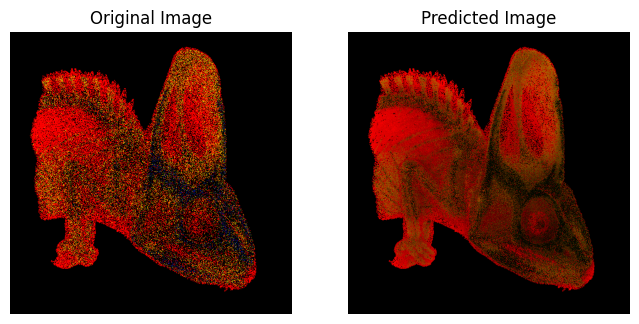

In [4]:
loss_fn = nn.MSELoss(reduction='mean')
model.eval()
with torch.no_grad():
    pred = model(Xs[-1])
loss = loss_fn(pred, ys[-1])
print(f'Loss: {loss.item():.5f}')

original = create_image(ys[-1], masks[-1], parameters['resolution'])
predicted = create_image(pred, masks[-1], parameters['resolution'])

_, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(original)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(predicted)
ax[1].set_title('Predicted Image')
ax[1].axis('off')
plt.show()

## Export


In [5]:
torch.onnx.export(
    model,
    Xs[-1],
    '../data/models/model.onnx',
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'num_pixels'},
        'output': {0: 'num_pixels'},
    },
    external_data=False,
)

/tmp/ipykernel_244997/1894377388.py:1: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0309 00:56:37.374000 244997 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0309 00:56:37.375000 244997 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0309 00:56:37.375000 244997 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `RadianceFieldNetwork([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RadianceFieldNetwork([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/home/blaz/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 3 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[num_pixels,5]>
            ),
            outputs=(
                %"output"<FLOAT,[num_pixels,3]>
            ),
            initializers=(
                %"position_encoding.tables.0.weight"<FLOAT,[729,5]>{TorchTensor(...)},
                %"position_encoding.tables.1.weight"<FLOAT,[1331,5]>{TorchTensor(...)},
                %"position_encoding.tables.2.weight"<FLOAT,[2744,5]>{TorchTensor(...)},
                %"position_encoding.tables.3.weight"<FLOAT,[6859,5]>{TorchTensor(...)},
                %"position_encoding.tables.4.weight"<FLOAT,[15625,5]>{TorchTensor(...)},
                %"position_encoding.tables.5.weight"<FLOAT,[32768,5]>{Torch

## Inference


ONNX Loss: 0.05782


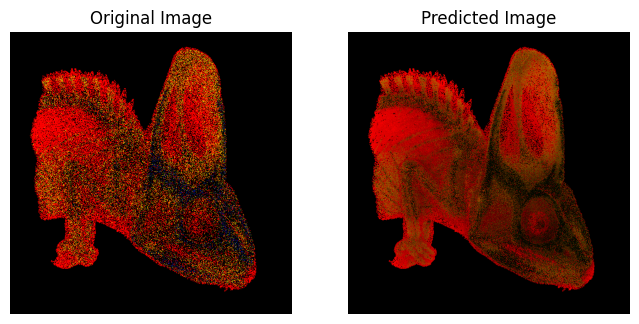

In [6]:
onnx_model = onnx.load('../data/models/model.onnx')
onnx.checker.check_model(onnx_model)

sess_options = ort.SessionOptions()
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

ort_sess = ort.InferenceSession(
    '../data/models/model.onnx',
    session_options=sess_options,
)
outputs = ort_sess.run(None, {'input': Xs[-1].cpu().numpy()})
outputs = torch.from_numpy(outputs[0]).to(device)

loss = loss_fn(outputs, ys[-1])
print(f'ONNX Loss: {loss.item():.5f}')

onnx_predicted = create_image(outputs, masks[-1], parameters['resolution'])

_, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(original)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(onnx_predicted)
ax[1].set_title('Predicted Image')
ax[1].axis('off')
plt.show()
